### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import pandas as pd

### Day 2 Exercises
#### Part 1: Geometric Distribution

p=0.05, n=10000
 Sample mean=19.9667, Theo mean=20.0000
 Sample var =369.2300, Theo var =380.0000
 Chi-square statistic = 72.2667
 Chi-square p-value   = 0.9018
 Fail to reject H0: data are consistent with a geometric distribution.


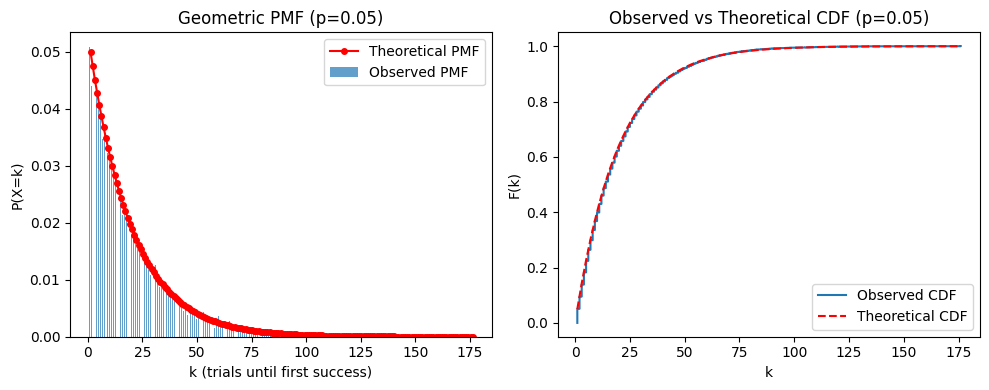

p=0.2, n=10000
 Sample mean=4.9492, Theo mean=5.0000
 Sample var =19.1132, Theo var =20.0000
 Chi-square statistic = 31.4390
 Chi-square p-value   = 0.2123
 Fail to reject H0: data are consistent with a geometric distribution.


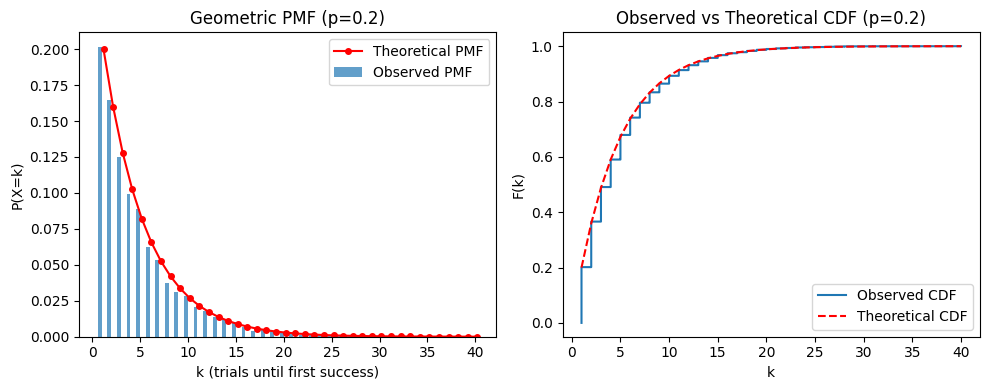

p=0.6, n=10000
 Sample mean=1.6661, Theo mean=1.6667
 Sample var =1.1222, Theo var =1.1111
 Chi-square statistic = 2.1522
 Chi-square p-value   = 0.9509
 Fail to reject H0: data are consistent with a geometric distribution.


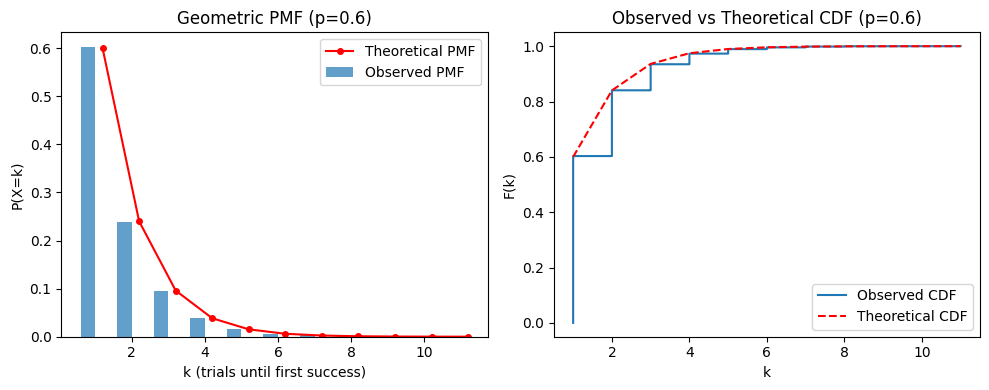

In [9]:
def compare_geom(p, n=10000, show_plots=True):
    samples = np.random.geometric(p, size=n)

    # empirical PMF
    max_k = int(max(samples.max(), stats.geom.ppf(0.999, p)))
    ks = np.arange(1, max_k + 1)
    counts = np.bincount(samples, minlength=max_k+1)[1:max_k+1]
    emp_pmf = counts / counts.sum()

    # theoretical PMF and CDF
    theo_pmf = stats.geom.pmf(ks, p)
    theo_cdf = stats.geom.cdf(ks, p)

    # print moments
    sample_mean = samples.mean()
    sample_var = samples.var(ddof=0)
    theo_mean = 1.0 / p
    theo_var = (1 - p) / (p**2)
    print(f"p={p:.3g}, n={n}")
    print(f" Sample mean={sample_mean:.4f}, Theo mean={theo_mean:.4f}")
    print(f" Sample var ={sample_var:.4f}, Theo var ={theo_var:.4f}")

    # Chi-square test
    # Null hpothesis:The simulated data follow a geometric distribution with parameter 𝑝.
    # Alternative hypothesis: The simulated data do not follow a geometric distribution with parameter 𝑝.
    valid = theo_pmf * n >= 5
    O = counts[valid]
    E = (theo_pmf * n)[valid]

    chi2_stat = ((O - E)**2 / E).sum()
    df = len(O) - 1  # degrees of freedom
    chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, df)

    print(f" Chi-square statistic = {chi2_stat:.4f}")
    print(f" Chi-square p-value   = {chi2_pvalue:.4f}")
    if chi2_pvalue > 0.05:
        print(" Fail to reject H0: data are consistent with a geometric distribution.")
    else:
        print(" Reject H0: data differ from the geometric distribution.")


    plt.figure(figsize=(10,4))

    # PMF comparison
    plt.subplot(1,2,1)
    plt.bar(ks - 0.2, emp_pmf, width=0.4, label='Observed PMF', color='C0', alpha=0.7)
    plt.plot(ks + 0.2, theo_pmf, 'r.-', label='Theoretical PMF', markersize=8)
    plt.xlabel('k (trials until first success)')
    plt.ylabel('P(X=k)')
    plt.title(f'Geometric PMF (p={p})')
    plt.legend()

    # CDF comparison (observed step vs theoretical)
    plt.subplot(1,2,2)
    x_sorted = np.sort(samples)
    y_emp = np.arange(1, n+1) / n
    plt.step(x_sorted, y_emp, where='post', label='Observed CDF', color='C0')
    xs = np.arange(1, max_k + 1)
    plt.plot(xs, theo_cdf, 'r--', label='Theoretical CDF')
    plt.xlabel('k')
    plt.ylabel('F(k)')
    plt.title(f'Observed vs Theoretical CDF (p={p})')
    plt.legend()

    plt.tight_layout()
    plt.show()

    
# Example runs: small, moderate, large p
for p_val in [0.05, 0.2, 0.6]:
    compare_geom(p_val, n=10000)

## Part 2

--- Statistical Tests ---
Direct Sampling Chi-Square p-value: 0.1703
  -> Fail to reject H0: Samples match theoretical distribution.
Rejection Sampling Chi-Square p-value: 0.5371
  -> Fail to reject H0: Samples match theoretical distribution.
Alias Sampling Chi-Square p-value: 0.7087
  -> Fail to reject H0: Samples match theoretical distribution.
 
Time Comparison for all 3 Sampling Methods
Direct Sampling took 0.0003 seconds
Rejection Sampling took 0.1837 seconds
Alias Sampling took 0.0003 seconds


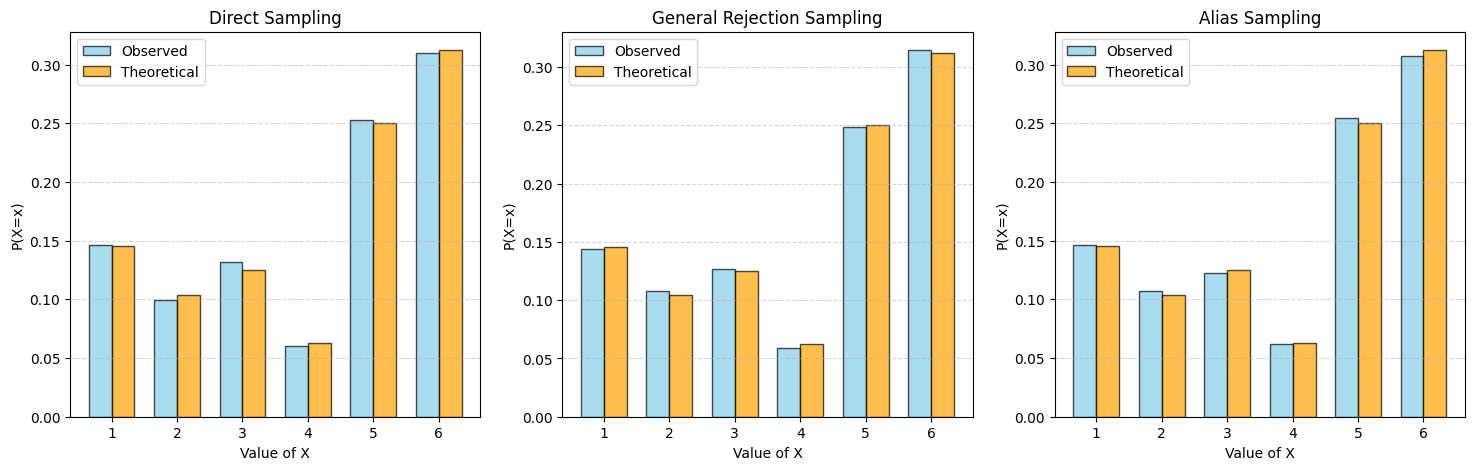

In [10]:
point_dist_dict = {1: 7/48,
                   2: 5/48,
                   3: 1/8,
                   4: 1/16,
                   5: 1/4,
                   6: 5/16}

values = np.array(sorted(point_dist_dict.keys()))
theoretical_probs = np.array([point_dist_dict[k] for k in values], dtype=float)
SAMPLE_SIZE = 10000

def direct_distribution_sampling(point_dist_dict, size=1):
    vals = np.array(sorted(point_dist_dict.keys()))
    probabilities = np.array([point_dist_dict[k] for k in vals], dtype=float)
    cumulative_probabilities = np.cumsum(probabilities)
    
    U = np.random.uniform(0, 1, size=size)
    idx = np.searchsorted(cumulative_probabilities, U, side='right')
    return vals[idx]

def rejection_sampling(point_dist_dict, size=1):
    vals = np.array(sorted(point_dist_dict.keys()))
    p = np.array([point_dist_dict[k] for k in vals], dtype=float)
    
    N = len(vals)
    q = np.ones(N) / N 
    c = np.max(p / q)
    
    accepted_samples = []
    while len(accepted_samples) < size:
        idx = np.random.choice(N, p=q)
        candidate = vals[idx]
        
        U = np.random.uniform(0, 1)
        p_I = p[idx]
        q_I = q[idx]
        
        if U <= p_I / (c * q_I):
            accepted_samples.append(candidate)
    return np.array(accepted_samples)

direct_samples = direct_distribution_sampling(point_dist_dict, size=SAMPLE_SIZE)
rejection_samples = rejection_sampling(point_dist_dict, size=SAMPLE_SIZE)

rng = DiscreteAliasUrn(theoretical_probs, random_state=np.random.default_rng())
alias_indices = rng.rvs(size=SAMPLE_SIZE)
alias_samples = values[alias_indices] 


def run_chisquare_test(samples, method_name):
    # Ensure all categories are counted correctly
    observed_counts = np.array([np.sum(samples == v) for v in values])
    expected_counts = theoretical_probs * SAMPLE_SIZE
    
    p_val = chisquare(f_obs=observed_counts, f_exp=expected_counts).pvalue
    print(f"{method_name} Chi-Square p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(f"  -> Reject H0: Samples do NOT match theoretical distribution.")
    else:
        print(f"  -> Fail to reject H0: Samples match theoretical distribution.")

print("--- Statistical Tests ---")
run_chisquare_test(direct_samples, "Direct Sampling")
run_chisquare_test(rejection_samples, "Rejection Sampling")
run_chisquare_test(alias_samples, "Alias Sampling")

def plot_on_axis(ax, samples, title_name):
    """Helper function to plot data on a specific subplot axis."""
    # Compute empirical probabilities ensuring missing values are accounted for
    observed_counts = np.array([np.sum(samples == v) for v in values])
    empirical_probs = observed_counts / SAMPLE_SIZE

    width = 0.35
    ax.bar(values - width/2, empirical_probs, width=width, label='Observed', alpha=0.7, color='skyblue', edgecolor='black')
    ax.bar(values + width/2, theoretical_probs, width=width, label='Theoretical', alpha=0.7, color='orange', edgecolor='black')
    
    ax.set_xticks(values)
    ax.set_xlabel('Value of X')
    ax.set_ylabel('P(X=x)')
    ax.set_title(title_name)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

def time_samplers():
    # Timing for Direct Sampling
    start = time.perf_counter()
    direct_samples = direct_distribution_sampling(point_dist_dict, size=SAMPLE_SIZE)
    end = time.perf_counter()
    print(f"Direct Sampling took {end - start:.4f} seconds")

    # Timing for Rejection Sampling
    start = time.perf_counter()
    rejection_samples = rejection_sampling(point_dist_dict, size=SAMPLE_SIZE)
    end = time.perf_counter()
    print(f"Rejection Sampling took {end - start:.4f} seconds")

    # Timing for Alias Sampling
    start = time.perf_counter()
    rng = DiscreteAliasUrn(theoretical_probs, random_state=np.random.default_rng())
    alias_indices = rng.rvs(size=SAMPLE_SIZE)
    alias_samples = values[alias_indices]
    end = time.perf_counter()
    print(f"Alias Sampling took {end - start:.4f} seconds")

print(' ')
print("Time Comparison for all 3 Sampling Methods")
time_samplers()

# Initialize a 1 row, 3 column plot grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Plot each method onto its corresponding column axis
plot_on_axis(axes[0], direct_samples, 'Direct Sampling')
plot_on_axis(axes[1], rejection_samples, 'General Rejection Sampling')
plot_on_axis(axes[2], alias_samples, 'Alias Sampling')